In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [16]:
#Calculate Forward Price
def forward_price (S0: float, r: float, q:float, T: float):
    "Theoretical forward price under continuous compounding:"
    "F = S0 * exp(r*T)"
    return S0 * math.exp((r-q) * T)

#Detect Arbitrage
def detect_arbitrage (S0,r,q,T,F_market):
    F_theoretical = forward_price(S0,r,q,T)

    if F_market > F_theoretical:
        return "Cash-and-carry arbitrage (Forward overpriced)"
    elif F_market < F_theoretical:
        return "Reverse Cash-and-carry (Forward underpriced)"
    else:
        return "No arbitrage"

#Arbitrage Profit
def arbitrage_profit (S0, r, T, q, F_market, tol=1e-6):
    diff= F_market - F_theoretical

    if abs (diff) <= tol:
        return 0.0, "No arbitrage (Within tolerance)"
    elif diff > tol:
        return diff, "Cash-and-carry (Forward overpriced)"
    else:
        return -diff, "Reverse cash-and-carry (Forward undepriced)"
    
    

102.02013400267558
Cash-and-carry arbitrage (Forward overpriced)
Arbitrage profit at maturity (per unit): 17.979865997324424


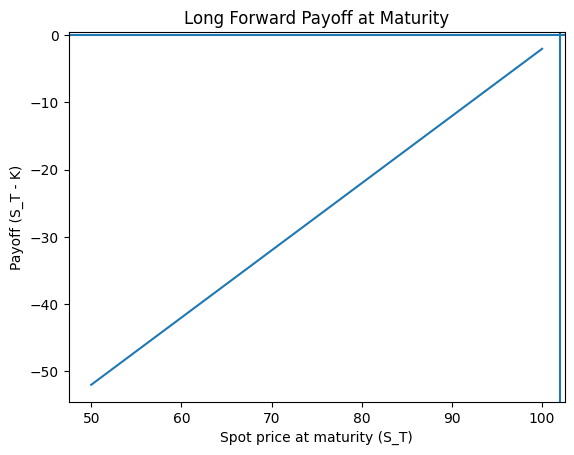

Fair forward K = 102.02013400267558


In [19]:
if __name__ == "__main__":
    S0 = 100 #Intial spot price
    r = 0.05 #Risk free rate per year
    T = 1 # Maturity time
    q = 0.03 #Dividend per year
    F_theoretical = forward_price(S0,r,q,T)
    F_market = 120
    print(F_theoretical)
    print(detect_arbitrage(S0,r,T,q,F_market))
    profit,label = arbitrage_profit(S0, r, T, q, F_market)
    print (f"Arbitrage profit at maturity (per unit):",profit)
    S_T = np.linspace (50,100,150) # Range of possible future spot prices
    K = forward_price (S0,r,q,T)
    payoff = S_T - K

    plt.figure()
    plt.plot(S_T, payoff)
    plt.axhline(0)
    plt.axvline(K)
    plt.title("Long Forward Payoff at Maturity")
    plt.xlabel("Spot price at maturity (S_T)")
    plt.ylabel("Payoff (S_T - K)")
    plt.show()
    print("Fair forward K =" , K)